# Hawkes Process — simulation & MLE calibration

$$\lambda^*(t) = \mu + \sum_{t_i < t} \alpha \cdot e^{-\beta(t-t_i)}$$

Log-likelihood (Ozaki 1979):
$$\ell = \sum_i \log \lambda^*(t_i) - \mu T - \frac{\alpha}{\beta}\sum_i\left[1 - e^{-\beta(T-t_i)}\right]$$

In [1]:
import sys
sys.path.insert(0, '../src')

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy.stats import probplot, kstest

from hawkes import HawkesProcess, calibrate, moment_estimator

## 1. Simulation

In [2]:
MU, ALPHA, BETA = 1.0, 0.55, 2.5
T = 2000.0

hp    = HawkesProcess(mu=MU, alpha=ALPHA, beta=BETA)
times = hp.simulate(T=T, seed=42)

print(hp)
print(f'branching ratio n = {hp.branching_ratio:.3f}  (< 1 -> stationary)')
print(f'stationary intensity = {hp.stationary_intensity:.3f}')
print(f'simulated {len(times)} events over T={T}')

HawkesProcess(mu=1.0000, alpha=0.5500, beta=2.5000, n=0.220)
branching ratio n = 0.220  (< 1 -> stationary)
stationary intensity = 1.282
simulated 2632 events over T=2000.0


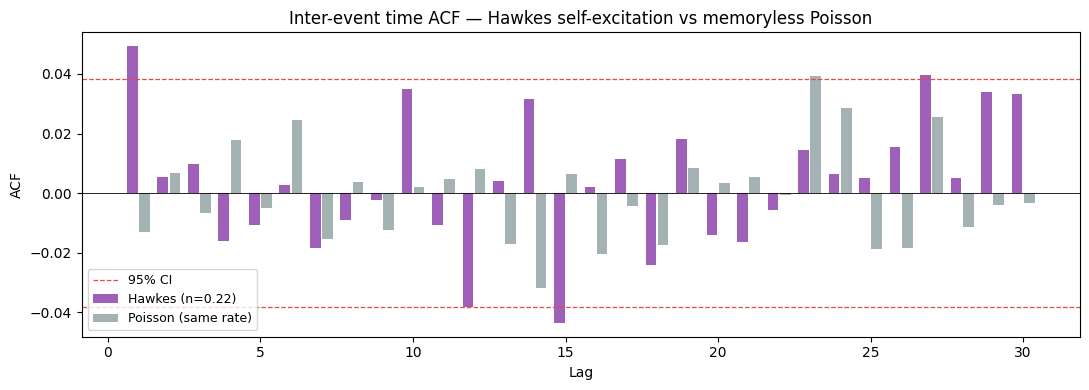

In [3]:
# if Hawkes, inter-event times should show positive autocorrelation (clustering)
# compare with Poisson which is memoryless -> ACF near zero by construction

def empirical_acf(x, nlags=30):
    x = np.asarray(x, dtype=float) - x.mean()
    acov = np.correlate(x, x, mode='full')[len(x)-1:]
    return acov[:nlags+1] / acov[0]

dt_hawkes = np.diff(times)
dt_poisson = np.random.default_rng(7).exponential(dt_hawkes.mean(), size=len(dt_hawkes))

lags  = np.arange(1, 31)
acf_h = empirical_acf(dt_hawkes)[1:]
acf_p = empirical_acf(dt_poisson)[1:]
ci    = 1.96 / np.sqrt(len(dt_hawkes))

fig, ax = plt.subplots(figsize=(11, 4))
ax.bar(lags - 0.2, acf_h, width=0.35, alpha=0.85, color='#8e44ad', label=f'Hawkes (n={hp.branching_ratio:.2f})')
ax.bar(lags + 0.2, acf_p, width=0.35, alpha=0.85, color='#95a5a6', label='Poisson (same rate)')
ax.axhline( ci, color='#e74c3c', lw=0.9, ls='--', label='95% CI')
ax.axhline(-ci, color='#e74c3c', lw=0.9, ls='--')
ax.axhline(0,   color='black',   lw=0.6)
ax.set_xlabel('Lag')
ax.set_ylabel('ACF')
ax.set_title('Inter-event time ACF — Hawkes self-excitation vs memoryless Poisson')
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

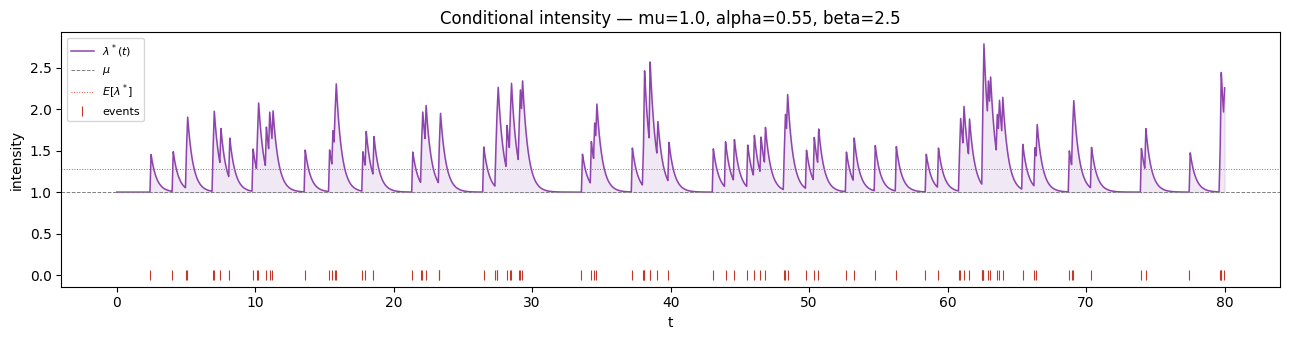

In [4]:
T_zoom = 80.0
grid, lam = hp.intensity_path(times, T=T_zoom, n_grid=1000)
t_zoom    = times[times <= T_zoom]

fig, ax = plt.subplots(figsize=(13, 3.5))
ax.fill_between(grid, MU, lam, alpha=0.12, color='#8e44ad')
ax.plot(grid, lam, color='#8e44ad', lw=1.1, label=r'$\lambda^*(t)$')
ax.axhline(MU, color='gray', lw=0.7, ls='--', label=r'$\mu$')
ax.axhline(hp.stationary_intensity, color='#e74c3c', lw=0.7, ls=':', label=r'$E[\lambda^*]$')
ax.plot(t_zoom, np.zeros_like(t_zoom), '|', color='#c0392b', ms=7, mew=0.8, label='events')
ax.set_xlabel('t')
ax.set_ylabel('intensity')
ax.set_title(f'Conditional intensity — mu={MU}, alpha={ALPHA}, beta={BETA}')
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

## 2. Moment estimator (warm start)

In [5]:
mu_mm, alpha_mm, beta_mm = moment_estimator(times, T)
print(f'true   : mu={MU:.4f}  alpha={ALPHA:.4f}  beta={BETA:.4f}')
print(f'moments: mu={mu_mm:.4f}  alpha={alpha_mm:.4f}  beta={beta_mm:.4f}')

true   : mu=1.0000  alpha=0.5500  beta=2.5000
moments: mu=0.9554  alpha=0.7220  beta=2.6350


## 3. MLE calibration

In [6]:
result = calibrate(times, T=T, n_restarts=6, verbose=True)
print('\n', result)

  restart 0: LL=-1841.9004  success=True
  restart 1: LL=-1831.5679  success=True
  restart 2: LL=-1831.5679  success=True
  restart 3: LL=-1831.5679  success=True
  restart 4: LL=-1831.5679  success=True
  restart 5: LL=-1831.5679  success=True

 CalibrationResult
  mu=1.026803  alpha=0.627715  beta=2.856060
  n=alpha/beta=0.2198
  log_likelihood=-1831.5679  N=2632  T=2000.0
  success=True


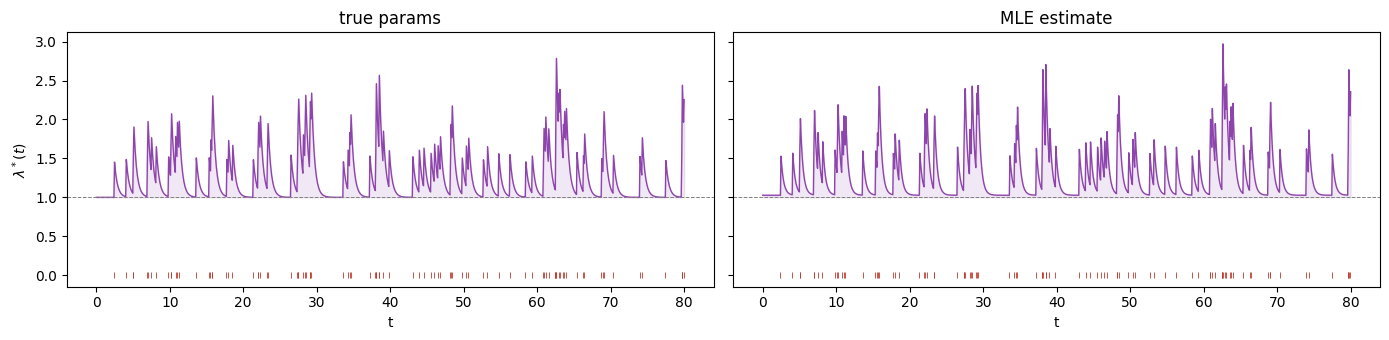

In [7]:
hp_est           = result.process
_, lam_est       = hp_est.intensity_path(times, T=T_zoom, n_grid=1000)

fig, axes = plt.subplots(1, 2, figsize=(14, 3.5), sharey=True)
for ax, lam_, title in zip(axes, [lam, lam_est], ['true params', 'MLE estimate']):
    ax.fill_between(grid, MU, lam_, alpha=0.12, color='#8e44ad')
    ax.plot(grid, lam_, color='#8e44ad', lw=1.0)
    ax.axhline(MU, color='gray', lw=0.7, ls='--')
    ax.plot(t_zoom, np.zeros_like(t_zoom), '|', color='#c0392b', ms=5, mew=0.6)
    ax.set_title(title)
    ax.set_xlabel('t')
axes[0].set_ylabel(r'$\lambda^*(t)$')
plt.tight_layout()
plt.show()

## 4. Goodness-of-fit — Ogata (1988) residuals

If the model is correct, the compensator increments $\Lambda(t_{i+1}) - \Lambda(t_i)$ should be iid **Exp(1)**.

In [ ]:
from scipy import stats

mu_e, alpha_e, beta_e = result.mu, result.alpha, result.beta

# Ogata residuals: compensator increments should be iid Exp(1) if model is correct
R, residuals = 1.0, np.empty(len(times) - 1)
for i in range(len(times) - 1):
    dt           = times[i + 1] - times[i]
    decay        = np.exp(-beta_e * dt)
    residuals[i] = mu_e * dt + (alpha_e / beta_e) * R * (1 - decay)
    R            = decay * R + 1.0

ks_stat, ks_pval = stats.kstest(residuals, 'expon')

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# QQ plot vs Exp(1)
q = (np.arange(1, len(residuals) + 1) - 0.5) / len(residuals)
axes[0].scatter(stats.expon.ppf(q), np.sort(residuals), s=4, alpha=0.5, color='#2980b9')
lim = np.sort(residuals)[-1]
axes[0].plot([0, lim], [0, lim], 'r--', lw=1)
axes[0].set_xlabel('Theoretical Exp(1)')
axes[0].set_ylabel('Empirical residuals')
axes[0].set_title('Q-Q — Ogata residuals')

# histogram
x = np.linspace(0, residuals.max(), 300)
axes[1].hist(residuals, bins=50, density=True, alpha=0.65, color='#2980b9', label='residuals')
axes[1].plot(x, stats.expon.pdf(x), 'r-', lw=2, label='Exp(1)')
axes[1].set_title(f'Residuals  (KS p-value = {ks_pval:.3f})')
axes[1].legend()

plt.tight_layout()
plt.show()

print(f"KS stat = {ks_stat:.4f}   p-value = {ks_pval:.4f}")

## 5. MLE convergence vs sample size

**Note on identifiability.** When looking at the convergence below, α and β don't converge independently — only their ratio n = α/β is well-identified. This makes sense: the likelihood surface is basically flat along the ridge α/β = const, so the optimizer can trade off α against β freely. Took a while to understand why the restarts were giving inconsistent individual values.

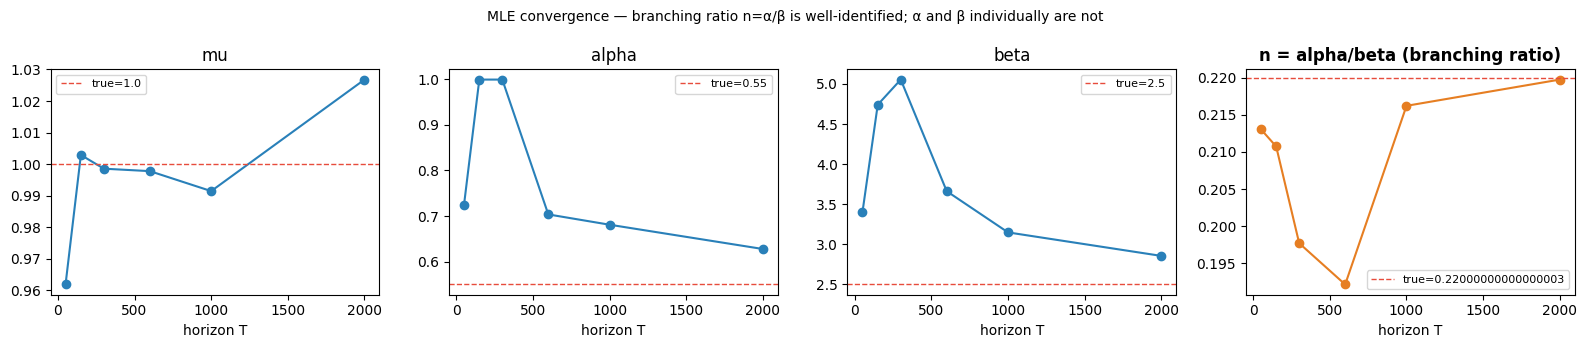

In [ ]:
horizons              = [50, 150, 300, 600, 1000, 2000]
mu_h, alpha_h, beta_h, n_h = [], [], [], []

for T_t in horizons:
    r = calibrate(times[times <= T_t], T=T_t, n_restarts=3, verbose=False)
    mu_h.append(r.mu); alpha_h.append(r.alpha)
    beta_h.append(r.beta); n_h.append(r.branching_ratio)

fig, axes = plt.subplots(1, 4, figsize=(16, 3.5))
params = [
    (mu_h,    MU,           'mu',            False),
    (alpha_h, ALPHA,        'alpha',         False),
    (beta_h,  BETA,         'beta',          False),
    (n_h,     ALPHA / BETA, 'n = alpha/beta (branching ratio)', True),
]
for ax, (vals, true, name, highlight) in zip(axes, params):
    color = '#e67e22' if highlight else '#2980b9'
    ax.plot(horizons, vals, 'o-', color=color, ms=6, lw=1.5)
    ax.axhline(true, color='#e74c3c', ls='--', lw=1, label=f'true={true}')
    ax.set_xlabel('horizon T')
    ax.set_title(name, fontweight='bold' if highlight else 'normal')
    ax.legend(fontsize=8)

plt.suptitle('MLE convergence — branching ratio n=α/β is well-identified; α and β individually are not', fontsize=10)
plt.tight_layout()
plt.show()